In [7]:
%load_ext autoreload
%autoreload 2

In [8]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2
from evaluation.metrics import plot_comprehensive_calibration
from models.MLP_balancing import balancing_mlp
import pickle
from pathlib import Path
import os


c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-p

In [11]:
echo_filter = True
overlap = 0.5

dir = Path(os.getcwd()).resolve().parent / "data" 
for i,encoder in enumerate(["effnetb0","perch2","NLM_BEATs"]):
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder)
    batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                                root_dir=str(dir / "xenocanto-dataset"),
                                encoder = encoder,
                                filter_echo=echo_filter,
                                overlap=overlap)
    preprocessed_audio,labels = batdata[i]
    print(f"Shape of preprocessed audio : {preprocessed_audio.shape}")
    encoded_window = extract_feature(preprocessed_audio[i], encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {encoded_window.shape}")
    #features,labels = build_feature_bank(batdata, encoder_model, encoder, device='cpu')

Testing encoder: effnetb0
Shape of preprocessed audio : torch.Size([104, 160000])
Shape of encoder features : torch.Size([1, 1280, 4, 32])
Testing encoder: perch2



KeyboardInterrupt: 

In [ ]:
dir = Path(os.getcwd()).resolve().parent / "data" 
for encoder in ["effnetb0","perch2","NLM_BEATs"]:
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder)
    batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                                root_dir=str(dir / "xenocanto-dataset"),
                                encoder = encoder)
    print("bat data extraction")
    windows1,labels1 = batdata[0]
    windows2,labels2= batdata[1]
    print("bat data extraction succsessful")

    label_list = []
    label_list.append(labels1.numpy())
    label_list.append(labels2.numpy())

    feature_list = []
    feats1 = extract_feature(windows1, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats1.shape}")
    feature_list.append(feats1.numpy())
    feats2 = extract_feature(windows2, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats2.shape}")
    feature_list.append(feats2.numpy())

    pool = pool_features(feature_list, windows=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over windows : {pool.shape}")

    pool2 = pool_features(feature_list, windows=False, window_pooled=False, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches : {pool2[0].shape}, {pool2[1].shape}")

    pool3 = pool_features(pool, windows=False, window_pooled=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches after window pooling: {pool3.shape}")



Testing encoder: effnetb0
bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 1280, 4, 32])
Shape of encoder features : torch.Size([3, 1280, 4, 32])
Shape of pooled features over windows : (2, 1280, 4, 32)
Shape of pooled features over patches : (104, 1280), (3, 1280)
Shape of pooled features over patches after window pooling: (2, 1280)
Testing encoder: perch2



bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 16, 4, 1536])
Shape of encoder features : torch.Size([3, 16, 4, 1536])
Shape of pooled features over windows : (2, 16, 4, 1536)
Shape of pooled features over patches : (104, 1536), (3, 1536)
Shape of pooled features over patches after window pooling: (2, 1536)
Testing encoder: NLM_BEATs
bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 496, 768])
Shape of encoder features : torch.Size([3, 496, 768])
Shape of pooled features over windows : (2, 496, 768)
Shape of pooled features over patches : (104, 768), (3, 768)
Shape of pooled features over patches after window pooling: (2, 768)


In [13]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_eff0 = np.load(path + "\\X_features2_not_normalized.npy")
X_NLM = np.load(path + "\\X_features_NLM.npy")
X_per2 = np.load(path + "\\perch_features.npz")['features']
y = np.load(path + "\\Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [5]:
print(X_eff0.shape, X_NLM.shape, X_per2.shape, y.shape)

(284, 1280, 4, 32) (284, 496, 768) (284, 1536) (284, 5)


In [84]:
#testing linear probe of effnetb0 
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
all_results = linear_probe_tuned(X_eff0_pooled, y[:,:4], n_split_out=2,n_split_in=2, num_trials=1,random_state=42)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: MLP
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/2
    Evaluating fold 2/2


In [89]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D']

results = compile_results(all_results,label_names=label_names,encoder="eff")
duplicated_results = {f"{model_name} (Run 2)": stats for model_name, stats in results.items()}
results = results | duplicated_results
#print(pd.DataFrame(results))
print(generate_metrics_table2(results,label_names=label_names)[0])

                            Model      Macro-AUC Macro-AP (cmAP)  \
0               eff Random Forest  0.899 ± 0.000   0.736 ± 0.000   
1                         eff SVM  0.892 ± 0.000   0.710 ± 0.000   
2                         eff MLP  0.917 ± 0.000   0.743 ± 0.000   
3          eff Prevalence guesser  0.479 ± 0.000   0.252 ± 0.000   
4       eff Random Forest (Run 2)  0.899 ± 0.000   0.736 ± 0.000   
5                 eff SVM (Run 2)  0.892 ± 0.000   0.710 ± 0.000   
6                 eff MLP (Run 2)  0.917 ± 0.000   0.743 ± 0.000   
7  eff Prevalence guesser (Run 2)  0.479 ± 0.000   0.252 ± 0.000   

   Brier Score ↓     Log-Loss ↓  
0  0.095 ± 0.000  0.313 ± 0.000  
1  0.090 ± 0.000  0.294 ± 0.000  
2  0.086 ± 0.000  0.505 ± 0.000  
3  0.163 ± 0.000  0.529 ± 0.000  
4  0.095 ± 0.000  0.313 ± 0.000  
5  0.090 ± 0.000  0.294 ± 0.000  
6  0.086 ± 0.000  0.505 ± 0.000  
7  0.163 ± 0.000  0.529 ± 0.000  


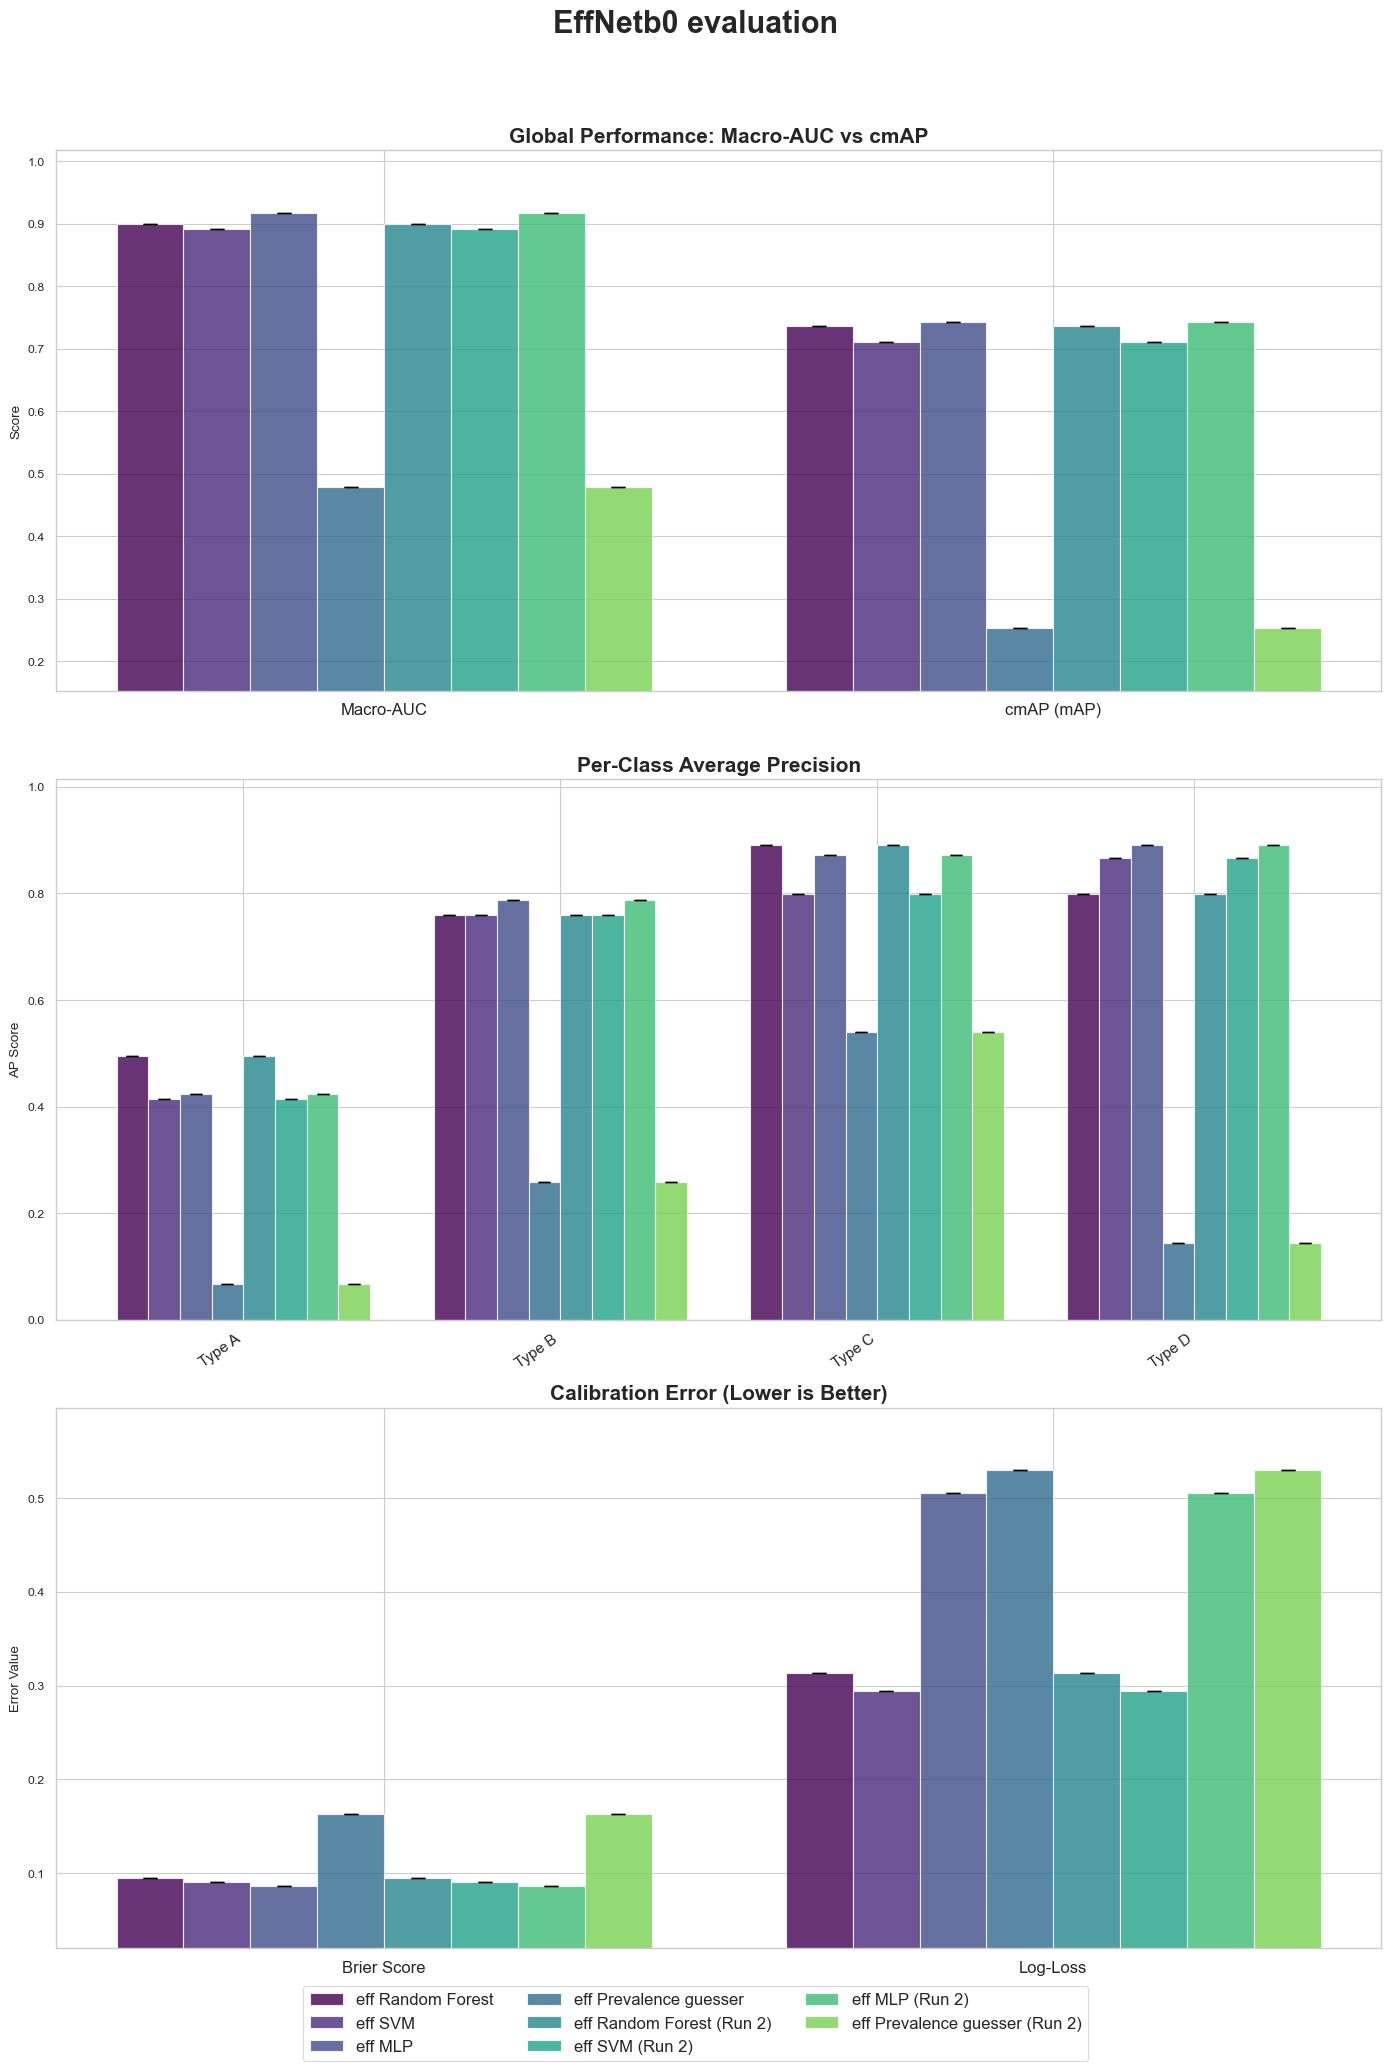

In [90]:
from evaluation.metrics import plot_comprehensive_results3

plot_comprehensive_results3(results, labels=label_names, title="EffNetb0 evaluation")

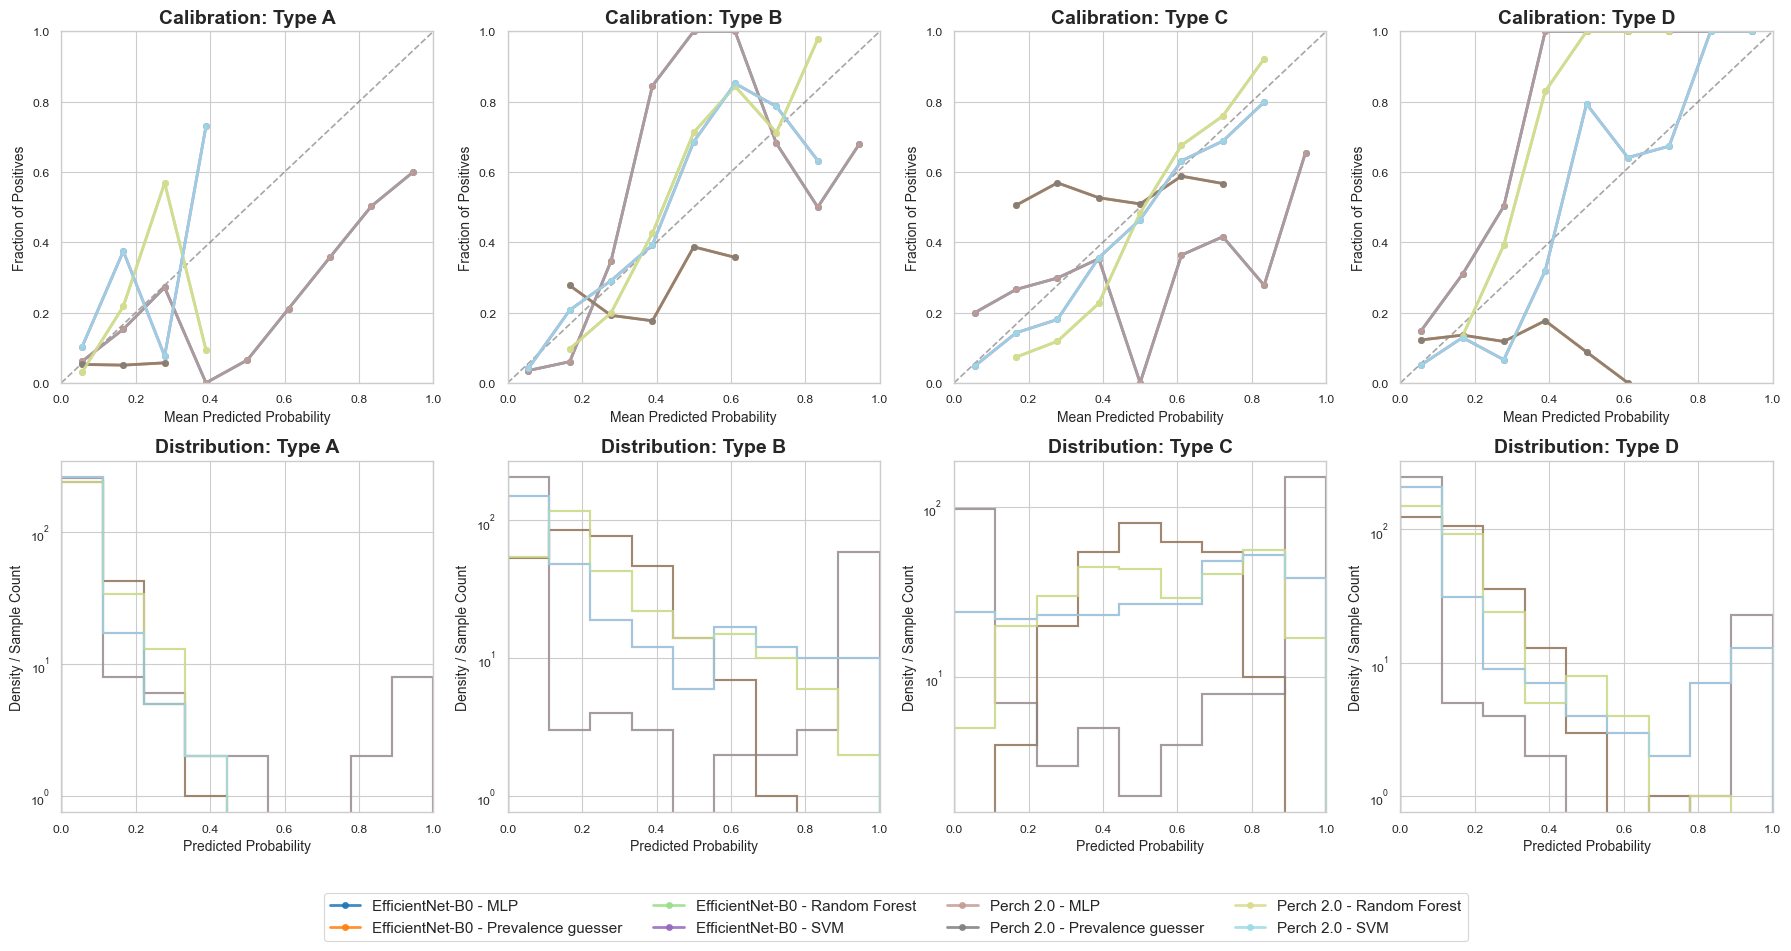

In [92]:
my_pipeline_results = {
    "EfficientNet-B0": all_results,                     # Your actual trial dictionary list
    "Perch 2.0": all_results    # Alternative encoder trial list
}

target_labels = ['Type A', 'Type B', 'Type C', 'Type D']

# 2. Render your visual evaluation assets
plot_comprehensive_calibration(
    encoder_results=my_pipeline_results, 
    label_names=target_labels, 
    n_bins=10, 
    strategy="uniform"
)

In [120]:
#Testing on balanced test set
from testing.linear_probe_tests import balanced_test
balanced_results = balanced_test(X_eff0_pooled, y, folds = 5, random_state=42)

Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: SVM, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: Random Forest, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: MLP, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: 

In [121]:
balanced_result = compile_results(balanced_results,label_names=label_names,encoder="eff_balanced")
print(generate_metrics_table2(balanced_result,label_names=label_names)[1])

                         Model      Type A AP      Type B AP      Type C AP  \
0   eff_balanced Random Forest  0.762 ± 0.181  0.873 ± 0.058  0.842 ± 0.071   
1             eff_balanced SVM  0.662 ± 0.195  0.922 ± 0.044  0.816 ± 0.068   
2             eff_balanced MLP  0.661 ± 0.200  0.918 ± 0.060  0.818 ± 0.078   
3  eff_balanced Random Guesser  0.175 ± 0.049  0.469 ± 0.082  0.516 ± 0.121   

       Type D AP  
0  0.930 ± 0.076  
1  0.959 ± 0.042  
2  0.937 ± 0.060  
3  0.334 ± 0.146  


In [127]:
balancing_results = balancing_mlp(X_eff0_pooled, y, n_split_out=2,n_split_in=2, num_trials=1,random_state=42)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/2
    Evaluating fold 2/2
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/2
Final counts: [119 118 145 118 234]
    Evaluating fold 2/2
Final counts: [118 118 132 118 246]


In [129]:
balancing_results_ = compile_results(balancing_results,label_names=label_names,encoder="eff_balanced")
print(generate_metrics_table2(balancing_results_,label_names=label_names)[0])

                           Model      Macro-AUC Macro-AP (cmAP)  \
0     eff_balanced MLP_FocalLoss  0.918 ± 0.000   0.804 ± 0.000   
1      eff_balanced MLP_Baseline  0.917 ± 0.000   0.815 ± 0.000   
2  eff_balanced MLP_ClassWeights  0.918 ± 0.000   0.811 ± 0.000   
3   eff_balanced MLP_Oversampled  0.922 ± 0.000   0.820 ± 0.000   

   Brier Score ↓     Log-Loss ↓  
0  0.077 ± 0.000  0.310 ± 0.000  
1  0.086 ± 0.000  0.488 ± 0.000  
2  0.083 ± 0.000  0.427 ± 0.000  
3  0.083 ± 0.000  0.555 ± 0.000  


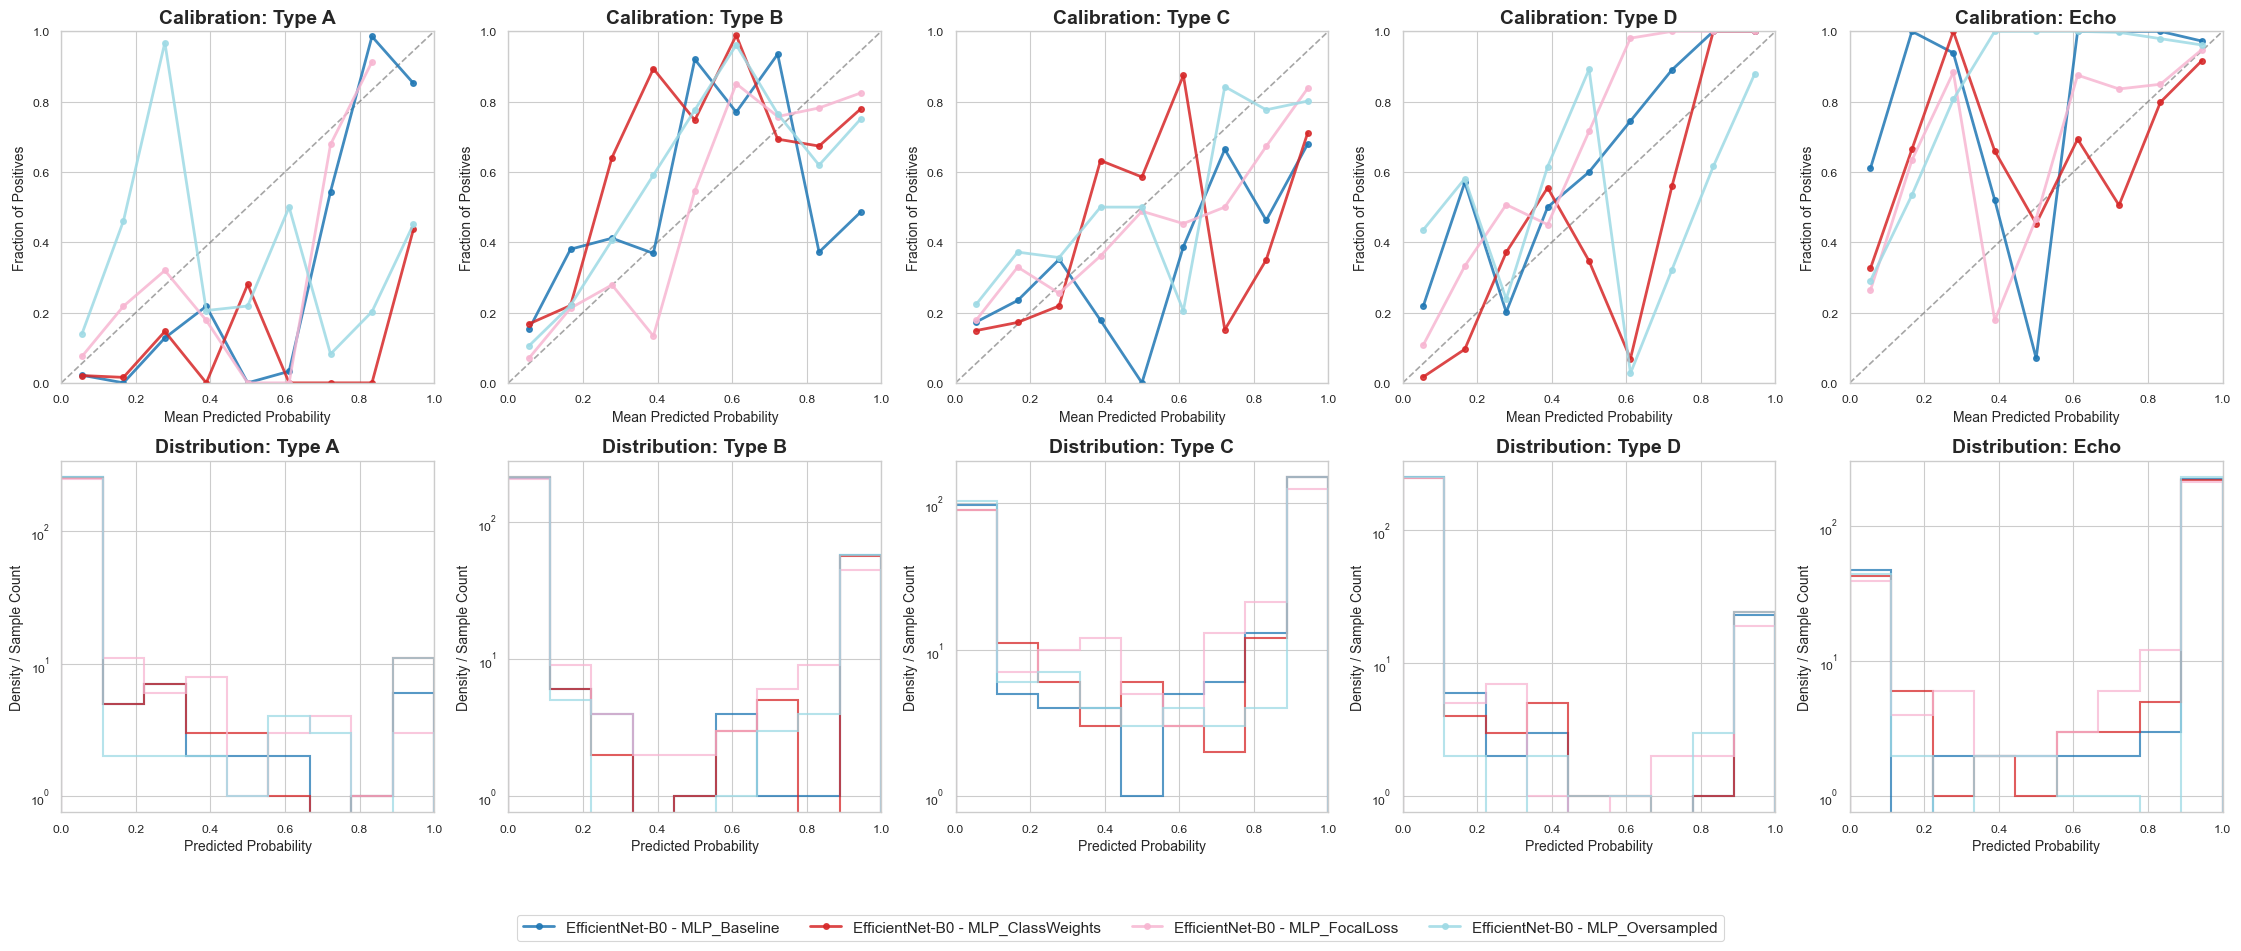

In [130]:
my_pipeline_results = {
    "EfficientNet-B0": balancing_results                  # Your actual trial dictionary list
}

target_labels = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

# 2. Render your visual evaluation assets
plot_comprehensive_calibration(
    encoder_results=my_pipeline_results, 
    label_names=target_labels, 
    n_bins=10, 
    strategy="uniform"
)

In [ ]:
#Testing feature extraction (without echo)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "effnetb0"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = 'encoder'
                             echo_filter = True)

features,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)

In [ ]:


#Write features
with open('features_perch_unpooled.txt','w+') as f :
    for items in features :
        f.write('%s\n' %items)
    print("file written")
f.close()
#Read features
with open('bat_features_mil.pkl','rb') as f :
    loaded_features = pickle.load(f) 


In [14]:
#implementing abMIL
current_dir = Path(os.getcwd()).resolve()
target_dir = current_dir.parent / "models" / "features"

with open(target_dir / "bat_features_mil.pkl", 'rb') as f:
    loaded_features = pickle.load(f)
y = np.load(target_dir / "Y_labels2_not_normalized.npy")
X_bags = pool_features(loaded_features, windows=False, window_pooled=False, method='mean', encoder='perch2')

In [19]:
from models.abmil_model import abmil_classifier_tuned
abmil_results =abmil_classifier_tuned(X_bags, y, n_split_out=2,n_split_in=2, num_trials=1,random_state=42)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: ABMIL
    Evaluating fold 1/2


KeyboardInterrupt: 